In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cpu_df = pd.read_csv(
    "../data/Processed/cpu_features.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

cpu_df["timestamp_display"] = (
    cpu_df["ts"]
    .dt.strftime("%d-%m-%Y %H:%M")
)
cpu_df["timestamp_display"].head()

0    02-04-2026 12:44
1    02-04-2026 12:46
2    02-04-2026 12:47
3    02-04-2026 12:49
4    02-04-2026 12:51
Name: timestamp_display, dtype: object

In [3]:
# Extract behaviour features
cpu_df["hour_of_day"] = (
    cpu_df["ts"].dt.hour
)

cpu_df["day_of_week"] = (
    cpu_df["ts"].dt.dayofweek
)
# Weekend flag
cpu_df["is_weekend"] = (
    cpu_df["day_of_week"] >= 5
).astype(int)

cpu_df[
    [
        "ts",
        "hour_of_day",
        "day_of_week",
        "is_weekend"
    ]
].head()

,ts,hour_of_day,day_of_week,is_weekend
0,2026-04-02 12:44:09.710000+00:00,12,3,0
1,2026-04-02 12:46:02.041000+00:00,12,3,0
2,2026-04-02 12:47:28.840000+00:00,12,3,0
3,2026-04-02 12:49:08.515000+00:00,12,3,0
4,2026-04-02 12:51:17.199000+00:00,12,3,0


In [4]:
# Save updated dataset
cpu_df.to_csv(
    "../data/Processed/cpu_baseline.csv",
    index=False
)

In [5]:
# Average CPU By Hour
# This tells us:
# Business Hours
# Peak CPU Hours
# Off-Peak Hours

hourly_cpu = (
    cpu_df
    .groupby("hour_of_day")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)
hourly_cpu

,hour_of_day,cpu_usage_pct
0,0,13.093041
1,1,13.194056
2,2,13.252071
3,3,13.203089
4,4,13.723424
5,5,14.036608
6,6,14.050952
7,7,14.002118
8,8,13.501888
9,9,14.063976


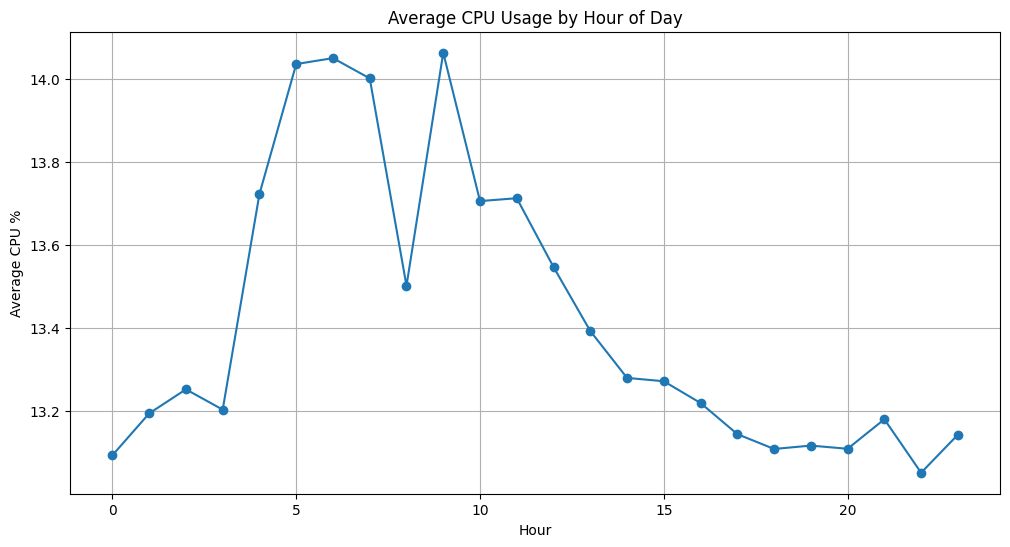

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    hourly_cpu["hour_of_day"],
    hourly_cpu["cpu_usage_pct"],
    marker="o"
)

plt.title(
    "Average CPU Usage by Hour of Day"
)

plt.xlabel("Hour")

plt.ylabel("Average CPU %")

plt.grid(True)

plt.show()

In [7]:
# Average CPU by weekday
days = {

    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
}

weekday_cpu = (
    cpu_df
    .groupby("day_of_week")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)

weekday_cpu["day"] = (
    weekday_cpu["day_of_week"]
    .map(days)
)

weekday_cpu

,day_of_week,cpu_usage_pct,day
0,0,13.475166,Mon
1,1,13.605941,Tue
2,2,13.330124,Wed
3,3,13.497802,Thu
4,4,13.589639,Fri
5,5,13.296046,Sat
6,6,13.156473,Sun


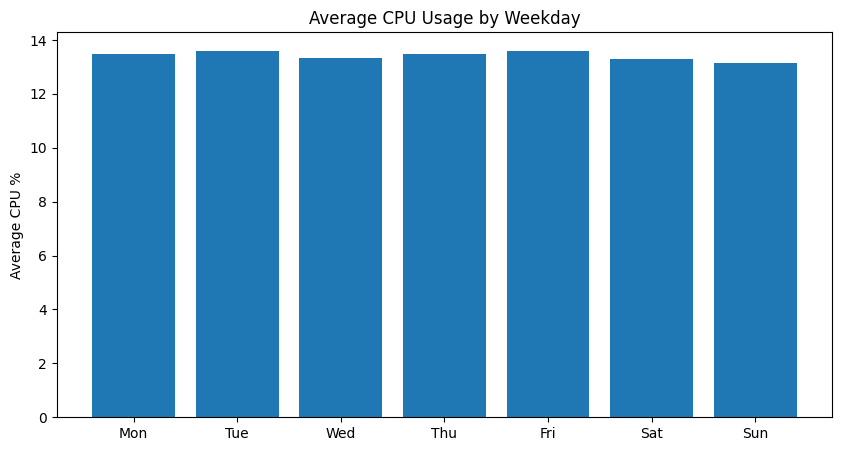

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday_cpu["day"],
    weekday_cpu["cpu_usage_pct"]
)

plt.title(
    "Average CPU Usage by Weekday"
)

plt.ylabel("Average CPU %")

plt.show()

In [9]:
# Average CPU by server
server_cpu = (
    cpu_df
    .groupby("hostName")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)
server_cpu

,hostName,cpu_usage_pct
0,10.10.10.150,7.783831
1,10.10.10.2,28.065299
2,10.10.10.65,4.405703


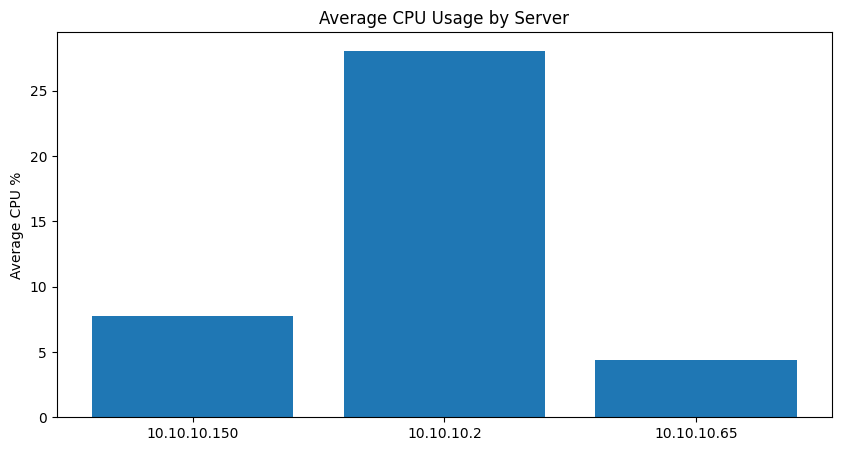

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    server_cpu["hostName"],
    server_cpu["cpu_usage_pct"]
)

plt.title(
    "Average CPU Usage by Server"
)

plt.ylabel("Average CPU %")

plt.show()

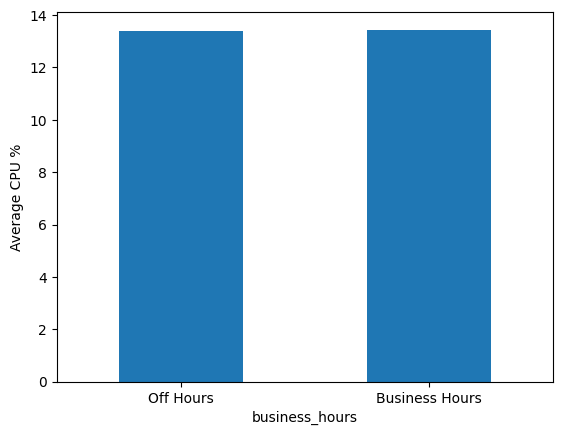

In [11]:
# Business hours vs Off hours
cpu_df["business_hours"] = (
    cpu_df["hour_of_day"]
    .between(8,18)
).astype(int)

cpu_df.groupby(
    "business_hours"
)["cpu_usage_pct"].mean()

business_cpu = (
    cpu_df
    .groupby("business_hours")
    ["cpu_usage_pct"]
    .mean()
)

business_cpu.plot(
    kind="bar"
)

plt.xticks(
    [0,1],
    ["Off Hours","Business Hours"],
    rotation=0
)

plt.ylabel(
    "Average CPU %"
)

plt.show()

In [12]:
# Peak CPU Period detection
hourly_cpu.sort_values(
    "cpu_usage_pct",
    ascending=False
).head(5)

,hour_of_day,cpu_usage_pct
9,9,14.063976
6,6,14.050952
5,5,14.036608
7,7,14.002118
4,4,13.723424
